In [ ]:
import numpy as np
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor

base_path = Path(r'C:\Users\wikto\Desktop\Google summer of code\dataset\train') #val
folders = ['no', 'sphere', 'vort']
dataset = {}

def load_file(f):
    return np.load(f)

for folder in folders:
    files = list((base_path / folder).glob('*.npy'))
    if not files: continue
    
    with ThreadPoolExecutor() as executor:
        images = list(executor.map(load_file, files))
    
    dataset[folder] = np.stack(images)
    print(f"Loaded {folder}: {dataset[folder].shape}")

Loaded no: (10000, 1, 150, 150)
Loaded sphere: (10000, 1, 150, 150)
Loaded vort: (10000, 1, 150, 150)


# Quality check

In [8]:
#shape check
first_label = list(dataset.keys())[0]
first_shape = dataset[first_label].shape[1:] 
print(f"Target shape: {first_shape}")

for label, data in dataset.items():
    current_shape = data.shape[1:]
    
    if current_shape != first_shape:
        print(f"{label} is {current_shape} but shouldn't")


#basic checks
print(f"{'Class':<10} | {'Total'} | {'Blank'} | {'Constant'} | {'NaN/Inf'}")

print("-" * 75)
for label, data in dataset.items():
    # All zeros
    is_blank = np.all(np.abs(data) < 1e-9, axis=(1, 2, 3))
    
    # Same values
    is_constant = np.max(data, axis=(1, 2, 3)) == np.min(data, axis=(1, 2, 3))
    is_constant = is_constant & ~is_blank 

    # Nans/Infs
    has_nan = np.any(~np.isfinite(data), axis=(1, 2, 3))



    print(f"{label:<10} | {len(data):<5} | {np.sum(is_blank):<5} | {np.sum(is_constant):<8} | {np.sum(has_nan):<7}")
    



Target shape: (1, 150, 150)
Class      | Total | Blank | Constant | NaN/Inf
---------------------------------------------------------------------------
no         | 10000 | 0     | 0        | 0      
sphere     | 10000 | 0     | 0        | 0      
vort       | 10000 | 0     | 0        | 0      


# Basic stats


--- Advanced Stats for NO ---
Signal to noise: 0.5254
Skewness       : 3.6694
Kurtosis       : 15.6005
RMS            : 0.1321
Zero-percentage: 0.0143

--- Advanced Stats for SPHERE ---
Signal to noise: 0.5257
Skewness       : 3.6555
Kurtosis       : 15.4533
RMS            : 0.1326
Zero-percentage: 0.0145

--- Advanced Stats for VORT ---
Signal to noise: 0.5271
Skewness       : 3.6488
Kurtosis       : 15.4105
RMS            : 0.1327
Zero-percentage: 0.0143


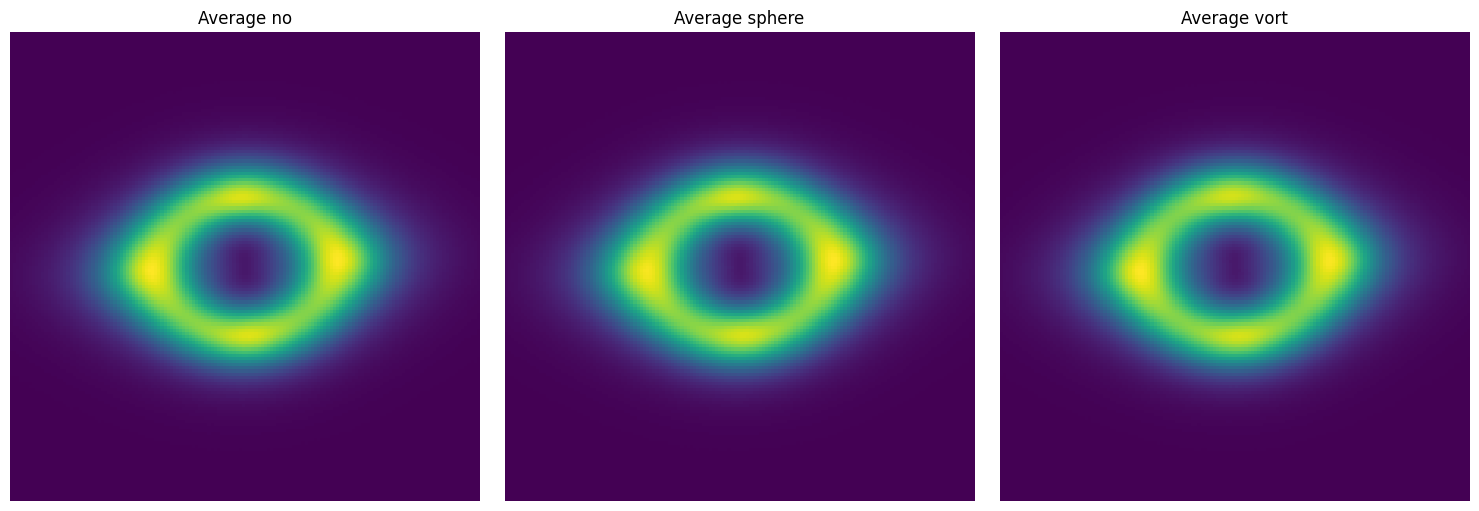

In [ ]:
import matplotlib.pyplot as plt
from scipy.stats import skew, kurtosis

def get_advanced_stats(data_array, label):
    flat_data = data_array.ravel()
    
    mean_val = np.mean(flat_data)
    std_val = np.std(flat_data)
    
    stats = {
        "Signal to noise": mean_val / std_val if std_val != 0 else 0, 
        "Skewness": skew(flat_data), #symmetry
        "Kurtosis": kurtosis(flat_data), #outliers, fatness of tails    
        "RMS": np.sqrt(np.mean(flat_data**2)),
        "Zero-percentage": (np.sum(flat_data == 0) / flat_data.size) * 100 #percentage of full 0s
    }
    
    print(f"\n--- Advanced Stats for {label.upper()} ---")
    for key, val in stats.items():
        print(f"{key:<15}: {val:.4f}")
    return stats

for label, data in dataset.items():
    get_advanced_stats(data, label)


plt.figure(figsize=(15, 5))

for i, (label, data) in enumerate(dataset.items()):
    mean_img = np.mean(data, axis=0).squeeze()
    
    plt.subplot(1, len(dataset), i+1)
    plt.imshow(mean_img)
    plt.title(f"Average {label}")
    plt.axis('off')

plt.tight_layout()
plt.show()

# Example viz

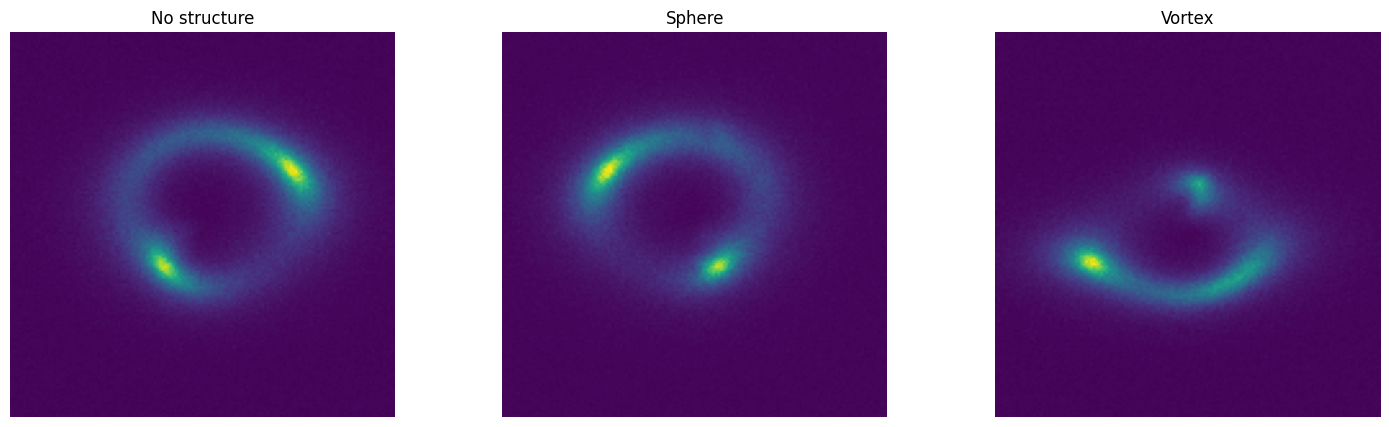

In [4]:
import numpy as np
import matplotlib.pyplot as plt

img1 = np.load(r'C:\Users\wikto\Desktop\Google summer of code\Code_basic_task\dataset\train\no\1.npy').squeeze()
img2 = np.load(r'C:\Users\wikto\Desktop\Google summer of code\Code_basic_task\dataset\train\sphere\1.npy').squeeze()
img3 = np.load(r'C:\Users\wikto\Desktop\Google summer of code\Code_basic_task\dataset\train\vort\1.npy').squeeze()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))


im1 = axes[0].imshow(img1)
axes[0].set_title('No structure')
axes[0].axis('off') 

im2 = axes[1].imshow(img2)
axes[1].set_title('Sphere')
axes[1].axis('off')

im3 = axes[2].imshow(img3)
axes[2].set_title('Vortex')
axes[2].axis('off')

plt.show()